# 🛰️ DOFA-EuroSAT Segmentation — Demo & Visualization

This notebook walks through the full inference pipeline and visualizes:
- Sample EuroSAT input patches
- Ground truth segmentation masks
- Model predictions vs ground truth
- Per-class IoU performance
- Confusion matrix
- Class distribution in the dataset

> **No GPU required** — runs on CPU in a few minutes.

## 0. Install Dependencies

In [16]:
# Uses subprocess.run to avoid Windows shell path issues with !{sys.executable}
import sys, subprocess

pkgs = [
    ["torch", "torchvision", "--index-url", "https://download.pytorch.org/whl/cpu"],
    ["rasterio", "pandas", "numpy", "matplotlib", "scikit-learn"],
    ["pytorch-lightning", "torchmetrics", "torchgeo"],
    ["segmentation-models-pytorch", "huggingface_hub"],
]

for group in pkgs:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q"] + group,
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"\u274c Failed: {group[0]}")
        print(result.stderr[-500:])
    else:
        print(f"\u2705 Installed: {group[0]}")

print('\n\u2705 All packages installed')

✅ Installed: torch
✅ Installed: rasterio
✅ Installed: pytorch-lightning
✅ Installed: segmentation-models-pytorch

✅ All packages installed


## 0. Setup & Imports

In [17]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from pathlib import Path
from sklearn.metrics import confusion_matrix

# Ensure geo_deep_learning is importable
import sys
sys.path.insert(0, str(Path('.').resolve()))

# Create outputs folder for saved figures
Path('outputs').mkdir(exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

print('\u2705 Imports successful')

✅ Imports successful


## 1. Class Definitions & Colour Palette

✅ Class palette defined


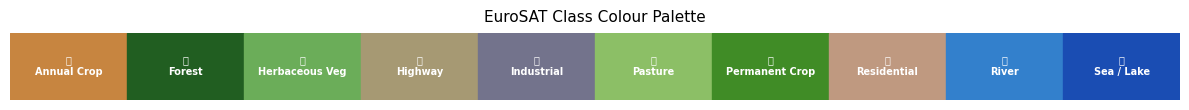

In [11]:
# ── EuroSAT class metadata ────────────────────────────────────────────
CLASS_NAMES = [
    'Annual Crop',       # 0
    'Forest',            # 1
    'Herbaceous Veg',    # 2
    'Highway',           # 3
    'Industrial',        # 4
    'Pasture',           # 5
    'Permanent Crop',    # 6
    'Residential',       # 7
    'River',             # 8
    'Sea / Lake',        # 9
]

CLASS_ICONS = ['\U0001f33e','\U0001f332','\U0001f33f','\U0001f6e3\ufe0f','\U0001f3ed','\U0001f404','\U0001f347','\U0001f3d8\ufe0f','\U0001f3de\ufe0f','\U0001f30a']

# Folder names in EuroSAT/2750/ mapped to class indices
FOLDER_TO_LABEL = {
    'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2,
    'Highway': 3, 'Industrial': 4, 'Pasture': 5,
    'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9,
}

# Distinct colours for each class (RGB 0-1)
CLASS_COLORS = [
    (0.78, 0.52, 0.25),   # Annual Crop   - wheat
    (0.13, 0.37, 0.13),   # Forest        - dark green
    (0.42, 0.68, 0.35),   # Herbaceous    - light green
    (0.65, 0.60, 0.45),   # Highway       - tan
    (0.45, 0.45, 0.55),   # Industrial    - grey-blue
    (0.55, 0.75, 0.40),   # Pasture       - lime green
    (0.25, 0.55, 0.15),   # Permanent Crop- olive green
    (0.75, 0.60, 0.50),   # Residential   - clay
    (0.20, 0.50, 0.80),   # River         - blue
    (0.10, 0.30, 0.70),   # Sea/Lake      - deep blue
]

CMAP = ListedColormap(CLASS_COLORS)

def mask_to_rgb(mask):
    rgb = np.zeros((*mask.shape, 3))
    for cls_id, color in enumerate(CLASS_COLORS):
        rgb[mask == cls_id] = color
    return rgb

def make_legend():
    return [
        mpatches.Patch(color=c, label=f'{CLASS_ICONS[i]} {CLASS_NAMES[i]}')
        for i, c in enumerate(CLASS_COLORS)
    ]

print('\u2705 Class palette defined')

fig, ax = plt.subplots(figsize=(12, 1.2))
for i, (color, name) in enumerate(zip(CLASS_COLORS, CLASS_NAMES)):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.text(i + 0.5, 0.5, f'{CLASS_ICONS[i]}\n{name}',
            ha='center', va='center', fontsize=7, color='white', fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('EuroSAT Class Colour Palette', fontsize=11, pad=8)
plt.tight_layout()
plt.savefig('outputs/00_class_palette.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Explore the Dataset — Sample Patches

In [18]:
# ── Auto-build train/val DataFrames from EuroSAT/2750/<ClassName>/*.jpg ──────
# No CSV files needed - splits are generated directly from folder structure
DATA_ROOT = Path('EuroSAT/2750')

records = []
for folder, label in FOLDER_TO_LABEL.items():
    class_dir = DATA_ROOT / folder
    for img_path in sorted(class_dir.glob('*.jpg')):
        records.append({'image_path': str(img_path), 'label': label})

random.seed(42)
random.shuffle(records)
split = int(len(records) * 0.8)
train_df = pd.DataFrame(records[:split])
val_df   = pd.DataFrame(records[split:])

print(f'Total images found : {len(records)}')
print(f'Training samples   : {len(train_df)}')
print(f'Validation samples : {len(val_df)}')
train_df.head()

Total images found : 27000
Training samples   : 21600
Validation samples : 5400


,image_path,label
0,EuroSAT\2750\River\River_771.jpg,8
1,EuroSAT\2750\PermanentCrop\PermanentCrop_723.jpg,6
2,EuroSAT\2750\AnnualCrop\AnnualCrop_1057.jpg,0
3,EuroSAT\2750\River\River_721.jpg,8
4,EuroSAT\2750\Pasture\Pasture_1161.jpg,5


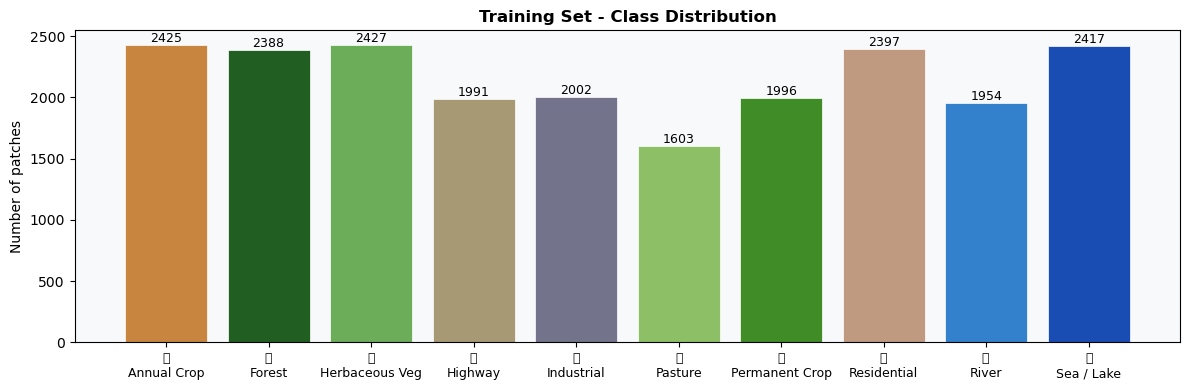

In [19]:
# ── Class distribution bar chart ────────────────────────────────────────────
class_counts = train_df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(
    range(len(CLASS_NAMES)),
    [class_counts.get(i, 0) for i in range(len(CLASS_NAMES))],
    color=CLASS_COLORS, edgecolor='white', linewidth=0.5
)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(
    [f'{CLASS_ICONS[i]}\n{CLASS_NAMES[i]}' for i in range(len(CLASS_NAMES))],
    fontsize=9
)
ax.set_ylabel('Number of patches', fontsize=10)
ax.set_title('Training Set - Class Distribution', fontsize=12, fontweight='bold')
ax.bar_label(bars, fontsize=9)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('outputs/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

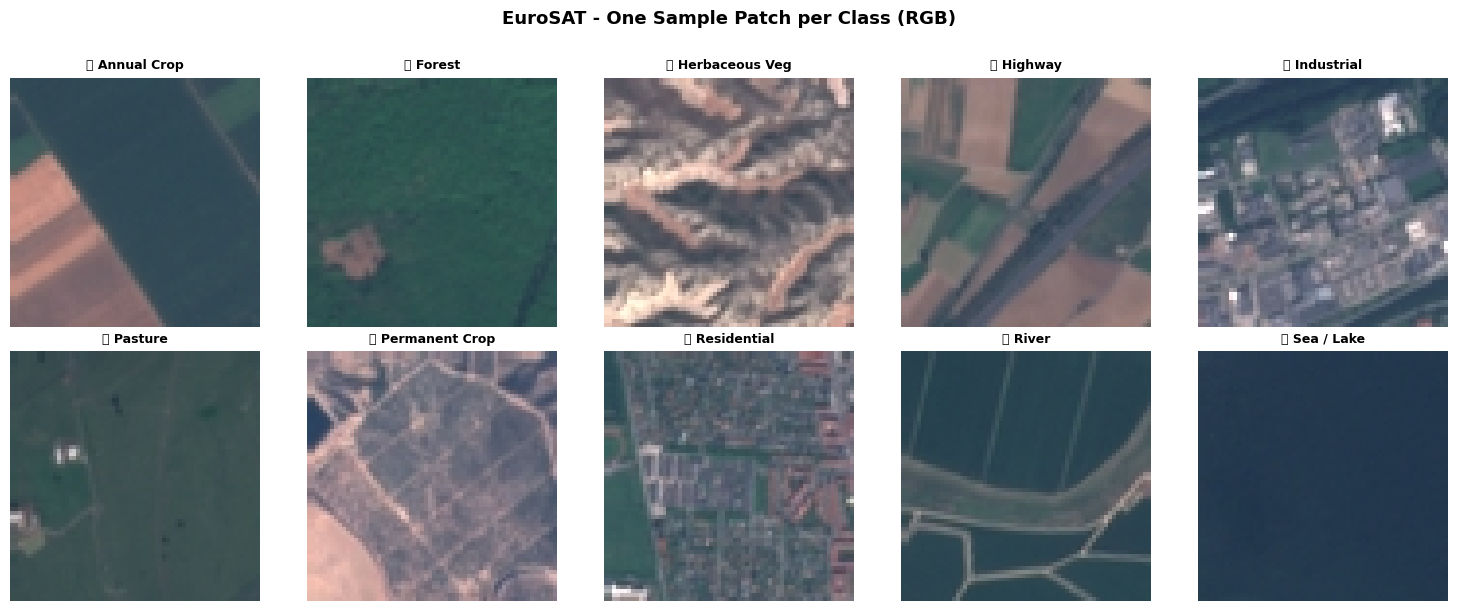

Each patch = 64x64 pixels of real Earth surface


In [20]:
# ── Show one sample patch per class ─────────────────────────────────────────
def load_rgb(image_path):
    """Load a JPG and return normalised RGB (H,W,3) array."""
    img = Image.open(image_path).convert('RGB')
    return np.array(img).astype(np.float32) / 255.0

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('EuroSAT - One Sample Patch per Class (RGB)',
             fontsize=13, fontweight='bold', y=1.01)

for cls_id, ax in enumerate(axes.flat):
    subset = train_df[train_df['label'] == cls_id]
    if len(subset) == 0:
        ax.axis('off')
        continue
    sample = subset.iloc[0]
    rgb = load_rgb(sample['image_path'])
    ax.imshow(rgb)
    ax.set_title(f'{CLASS_ICONS[cls_id]} {CLASS_NAMES[cls_id]}',
                 fontsize=9, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(CLASS_COLORS[cls_id])
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('outputs/02_sample_patches.png', dpi=150, bbox_inches='tight')
plt.show()
print('Each patch = 64x64 pixels of real Earth surface')

## 3. Load the Trained Model

In [21]:
import torch
from geo_deep_learning.tasks_with_models.segmentation_dofa import SegmentationDOFA
from geo_deep_learning.models.segmentation.dofa import DOFASegmentationModel

CHECKPOINT_PATH = 'logs/gdl_experiment/version_11/checkpoints/model-epoch=00-val_loss=0.141.ckpt'

# Load raw checkpoint — bypasses Lightning's class_path resolution
ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)

# Reconstruct model directly from hparams stored in checkpoint
hp = ckpt['hyper_parameters']
print("Hyperparameters found:", list(hp.keys()))

model = SegmentationDOFA(
    encoder       = hp['encoder'],
    pretrained    = False,                  # weights come from checkpoint, not HuggingFace
    image_size    = tuple(hp['image_size']),
    num_classes   = hp['num_classes'],
    max_samples   = hp.get('max_samples', 2),
    loss          = __import__('segmentation_models_pytorch').losses.DiceLoss(
                        mode='multiclass', from_logits=True),
    class_labels  = hp.get('class_labels'),
    class_colors  = hp.get('class_colors'),
    freeze_layers = hp.get('freeze_layers'),
)

# Manually load the state dict
model.configure_model()   # builds self.model internally
state = {k.removeprefix('model.'): v for k, v in ckpt['state_dict'].items()}
model.model.load_state_dict(state, strict=True)
model.eval()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model loaded')
print(f'   Total params     : {total_params/1e6:.1f}M')
print(f'   Trainable params : {trainable_params/1e6:.1f}M')

Hyperparameters found: ['_class_path', 'encoder', 'pretrained', 'image_size', 'num_classes', 'max_samples', 'loss', 'optimizer', 'scheduler', 'scheduler_config', 'freeze_layers', 'class_labels', 'class_colors', 'weights_from_checkpoint_path', '_instantiator']
✅ Model loaded
   Total params     : 140.3M
   Trainable params : 35.0M


## 4. Run Inference — Predictions vs Ground Truth

In [26]:
# ── Dataset: JPGs + uniform masks + wavelengths per batch ────────────────────
# model.forward(image, wavelengths) requires wavelengths in every batch
# Sentinel-2 R, G, B centre wavelengths in micrometres
WAVELENGTHS = torch.tensor([0.665, 0.549, 0.481])

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

class EuroSATDataset(Dataset):
    """Reads JPGs and generates uniform masks (entire patch = one class label)."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        h, w = image.shape[1], image.shape[2]
        # (1, H, W) — model squeezes to (B, H, W) internally
        mask = torch.full((1, h, w), label, dtype=torch.long)
        return {
            'image':       image,
            'mask':        mask,
            'label':       torch.tensor(label),
            'wavelengths': WAVELENGTHS,        # required by model.forward(image, wavelengths)
            'image_name':  row['image_path'],  # required by model visualization internals
        }

val_dataset = EuroSATDataset(val_df, transform=transform)
val_loader  = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f'\u2705 Validation dataset loaded: {len(val_dataset)} samples')

✅ Validation dataset loaded: 5400 samples


In [27]:
# ── Collect predictions for two batches (16 samples) ───────────────────────
DENORM_MEAN = torch.tensor(MEAN).view(3, 1, 1)
DENORM_STD  = torch.tensor(STD).view(3, 1, 1)

def denormalise(tensor):
    """Undo ImageNet normalisation for display."""
    return (tensor * DENORM_STD + DENORM_MEAN).permute(1, 2, 0).clamp(0, 1).numpy()

images_store, truths_store, preds_store, labels_store = [], [], [], []

with torch.no_grad():
    for batch in val_loader:
        images = batch['image']
        masks  = batch['mask'].squeeze(1)   # (B, H, W)
        wv     = batch['wavelengths']       # (B, 3)
        labels = batch['label']

        outputs = model(images, wv)         # returns namedtuple: .out (main), .aux (auxiliary)
        preds   = outputs.out.argmax(dim=1) # (B, H, W)

        images_store.append(images)
        truths_store.append(masks)
        preds_store.append(preds)
        labels_store.append(labels)
        if len(images_store) >= 2:          # 2 batches = 16 samples
            break

images_all = torch.cat(images_store)
truths_all = torch.cat(truths_store)
preds_all  = torch.cat(preds_store)
labels_all = torch.cat(labels_store)

print(f'\u2705 Predictions collected for {len(images_all)} samples')

✅ Predictions collected for 16 samples


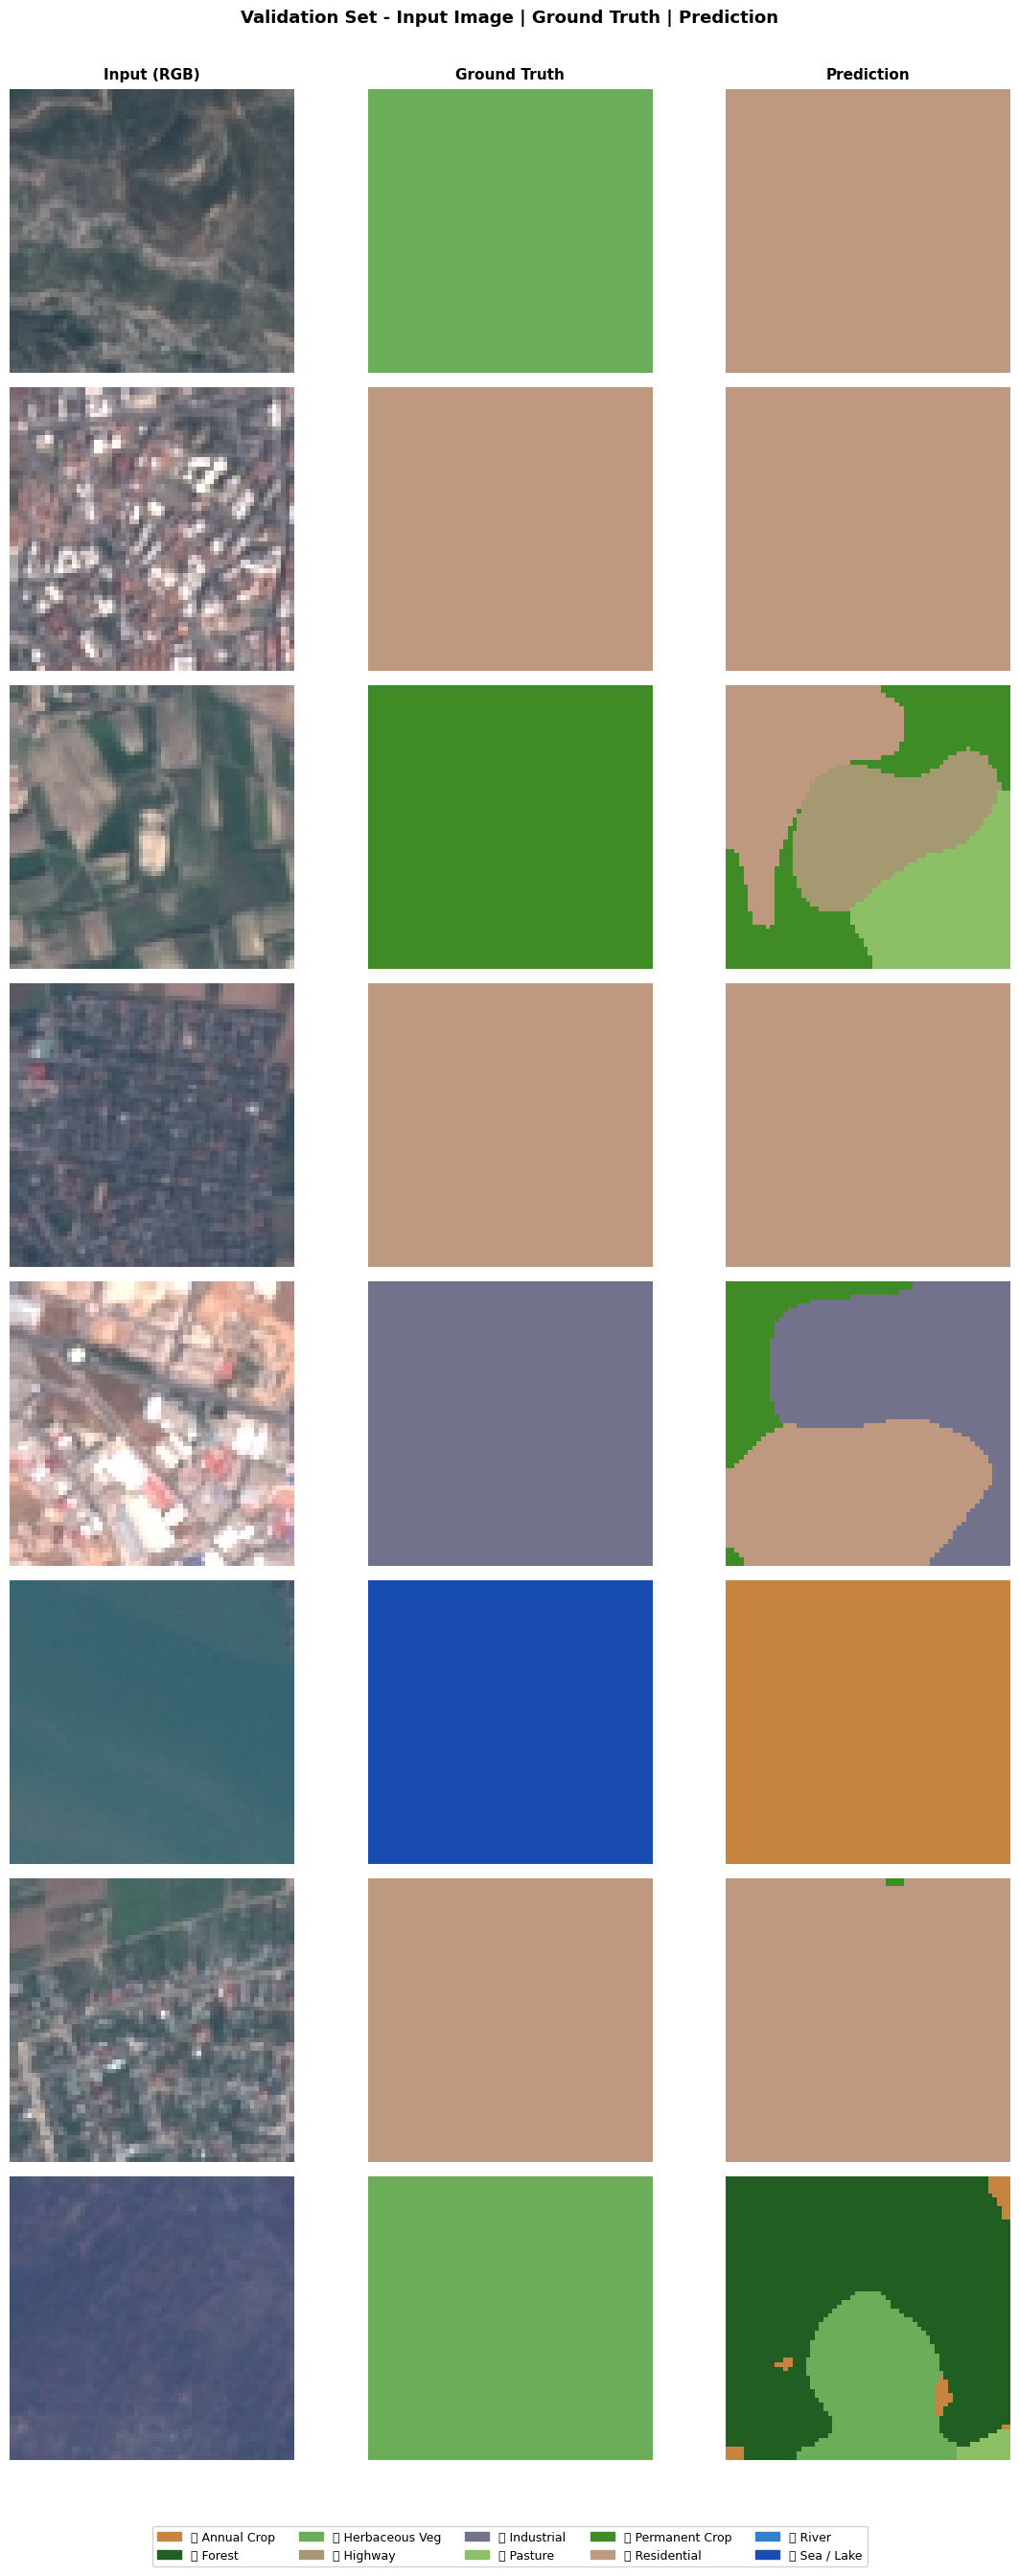

In [28]:
# ── Side-by-side: Input | Ground Truth | Prediction ────────────────────────
N_SHOW = 8

fig, axes = plt.subplots(N_SHOW, 3, figsize=(12, N_SHOW * 3.2))
fig.suptitle('Validation Set - Input Image | Ground Truth | Prediction',
             fontsize=13, fontweight='bold', y=1.005)

col_titles = ['Input (RGB)', 'Ground Truth', 'Prediction']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=8)

for i in range(N_SHOW):
    img   = denormalise(images_all[i])
    truth = truths_all[i].numpy()
    pred  = preds_all[i].numpy()
    cls   = labels_all[i].item()

    axes[i, 0].imshow(img)
    axes[i, 0].set_ylabel(f'{CLASS_ICONS[cls]} {CLASS_NAMES[cls]}',
                          fontsize=9, rotation=0, labelpad=80, va='center')
    axes[i, 1].imshow(mask_to_rgb(truth))
    axes[i, 2].imshow(mask_to_rgb(pred))

    for ax in axes[i]:
        ax.axis('off')

fig.legend(handles=make_legend(), loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.04), fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('outputs/03_predictions_grid.png', dpi=150, bbox_inches='tight')
plt.show()

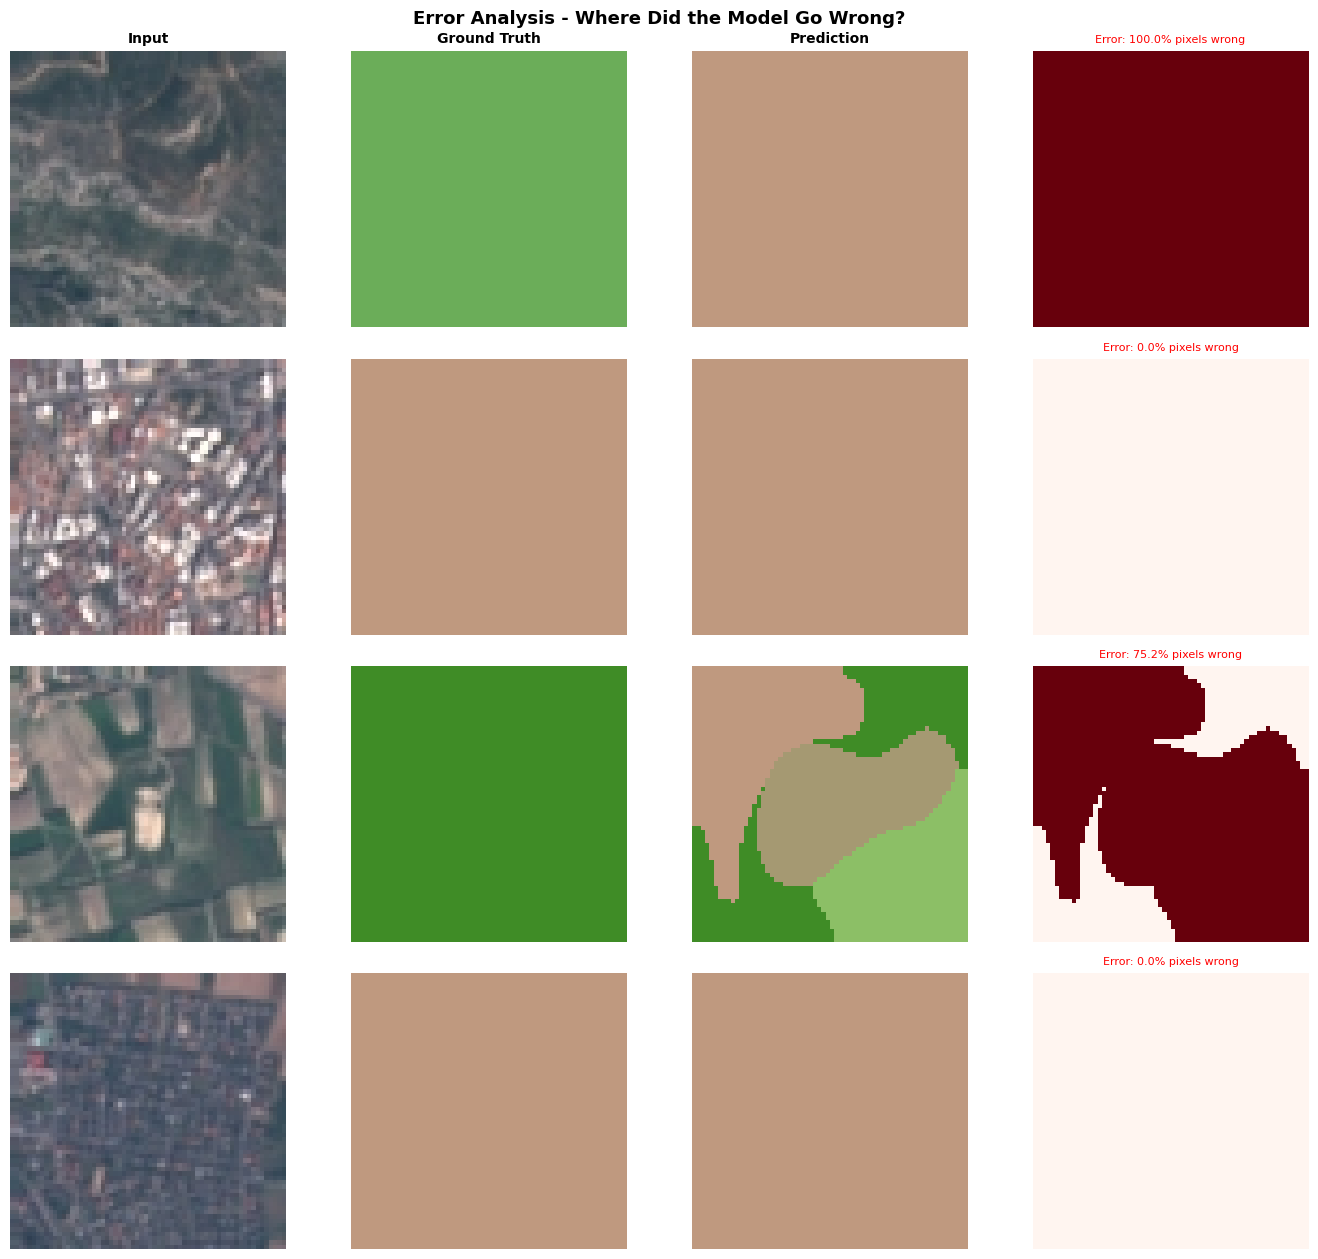

In [29]:
# ── Error map ─────────────────────────────────────────────────────────────
N_ERR = 4
fig, axes = plt.subplots(N_ERR, 4, figsize=(14, N_ERR * 3.2))
fig.suptitle('Error Analysis - Where Did the Model Go Wrong?',
             fontsize=13, fontweight='bold')

col_titles = ['Input', 'Ground Truth', 'Prediction', 'Error Map']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

for i in range(N_ERR):
    img   = denormalise(images_all[i])
    truth = truths_all[i].numpy()
    pred  = preds_all[i].numpy()
    error = (truth != pred).astype(np.float32)

    axes[i, 0].imshow(img)
    axes[i, 1].imshow(mask_to_rgb(truth))
    axes[i, 2].imshow(mask_to_rgb(pred))
    axes[i, 3].imshow(error, cmap='Reds', vmin=0, vmax=1)
    axes[i, 3].set_title(f'Error: {error.mean()*100:.1f}% pixels wrong',
                         fontsize=8, color='red')
    for ax in axes[i]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/04_error_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Quantitative Metrics - IoU per Class

In [30]:
# ── Compute IoU per class ───────────────────────────────────────────────
def compute_iou_per_class(preds, targets, num_classes=10):
    iou_list = []
    for cls in range(num_classes):
        pred_c   = (preds == cls)
        target_c = (targets == cls)
        intersection = (pred_c & target_c).sum().item()
        union        = (pred_c | target_c).sum().item()
        iou = intersection / (union + 1e-6)
        iou_list.append(iou)
    return iou_list

preds_flat  = preds_all.flatten()
truths_flat = truths_all.flatten()

iou_per_class = compute_iou_per_class(preds_flat, truths_flat)
mean_iou      = np.mean(iou_per_class)

print('\n\U0001f4ca Per-Class IoU Results')
print('-' * 40)
for i, (iou, name, icon) in enumerate(zip(iou_per_class, CLASS_NAMES, CLASS_ICONS)):
    bar = '#' * int(iou * 20)
    print(f'  {icon} {name:<18} {bar:<20} {iou:.3f}')
print('-' * 40)
print(f'  Mean IoU (mIoU): {mean_iou:.3f}')


📊 Per-Class IoU Results
----------------------------------------
  🌾 Annual Crop        ##########           0.529
  🌲 Forest                                  0.000
  🌿 Herbaceous Veg     ###                  0.187
  🛣️ Highway            ############         0.604
  🏭 Industrial         #########            0.463
  🐄 Pasture                                 0.002
  🍇 Permanent Crop     #####                0.284
  🏘️ Residential        ###########          0.552
  🏞️ River                                   0.000
  🌊 Sea / Lake                              0.000
----------------------------------------
  Mean IoU (mIoU): 0.262


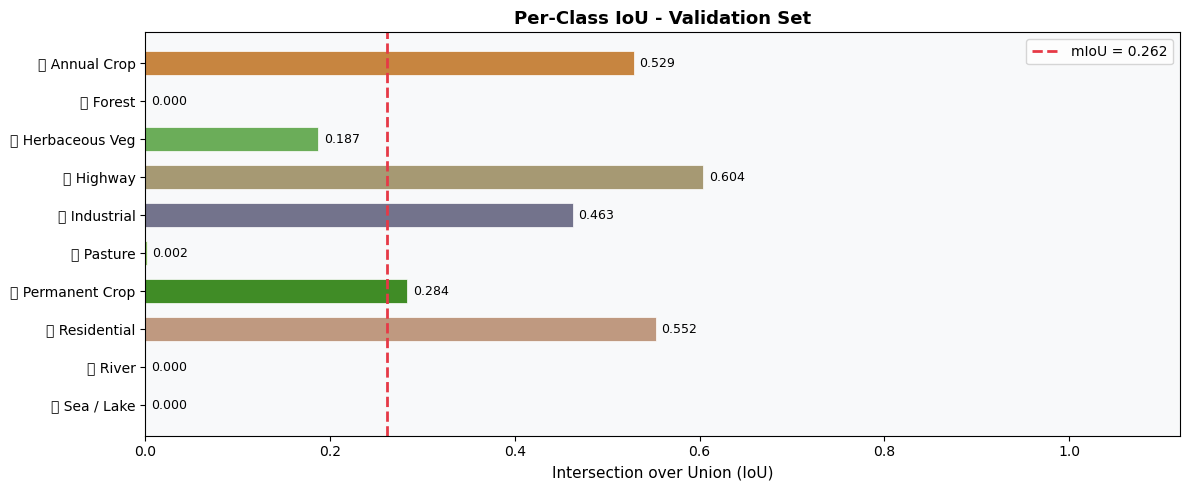

In [31]:
# ── IoU bar chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.barh(
    [f'{CLASS_ICONS[i]} {CLASS_NAMES[i]}' for i in range(10)],
    iou_per_class,
    color=CLASS_COLORS,
    edgecolor='white',
    linewidth=0.5,
    height=0.65
)

ax.axvline(mean_iou, color='#e63946', linewidth=2, linestyle='--',
           label=f'mIoU = {mean_iou:.3f}')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_xlim(0, 1.12)
ax.set_xlabel('Intersection over Union (IoU)', fontsize=11)
ax.set_title('Per-Class IoU - Validation Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/05_iou_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Confusion Matrix

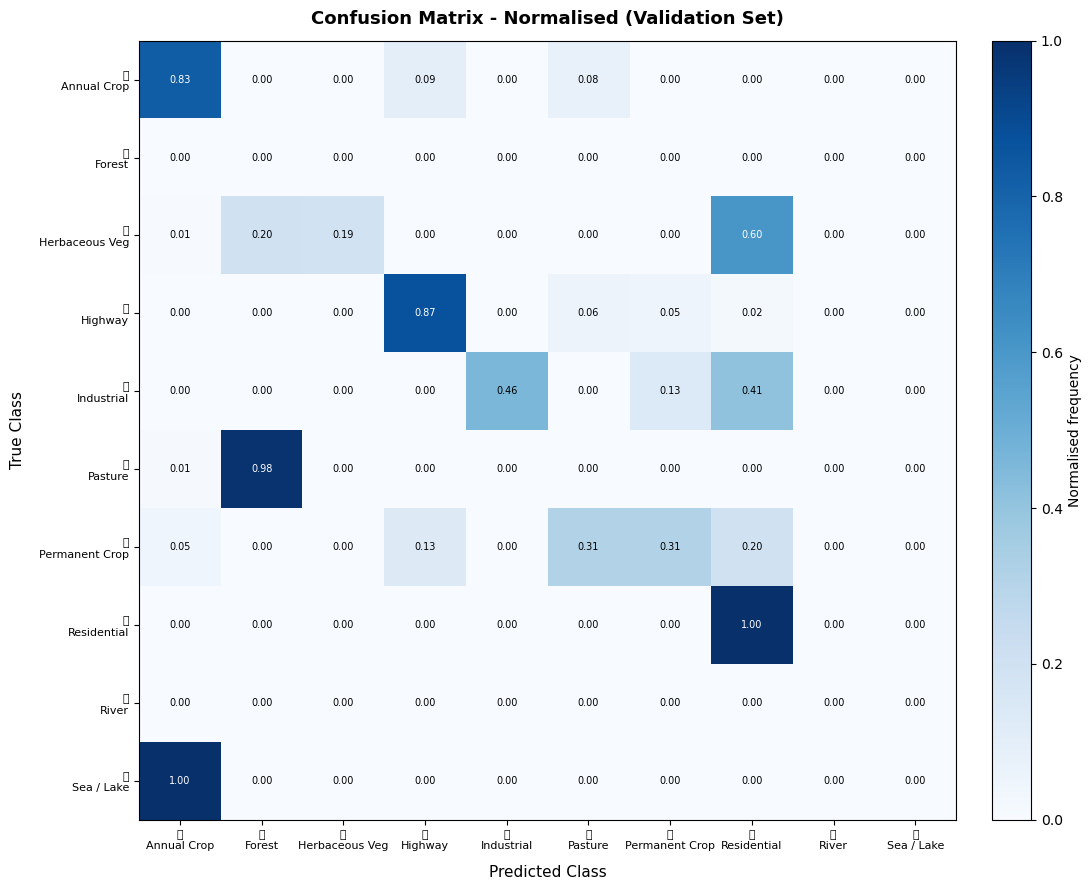

Diagonal = correct predictions. Off-diagonal = confused classes.


In [32]:
# ── Confusion matrix ───────────────────────────────────────────────────────
sample_idx = np.random.choice(len(preds_flat), size=min(50000, len(preds_flat)), replace=False)
p_sample = preds_flat[sample_idx].numpy()
t_sample = truths_flat[sample_idx].numpy()

cm = confusion_matrix(t_sample, p_sample, labels=list(range(10)), normalize='true')

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Normalised frequency')

tick_labels = [f'{CLASS_ICONS[i]}\n{CLASS_NAMES[i]}' for i in range(10)]
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_yticklabels(tick_labels, fontsize=8)

for i in range(10):
    for j in range(10):
        val = cm[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color=color)

ax.set_xlabel('Predicted Class', fontsize=11, labelpad=10)
ax.set_ylabel('True Class', fontsize=11, labelpad=10)
ax.set_title('Confusion Matrix - Normalised (Validation Set)',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('outputs/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Diagonal = correct predictions. Off-diagonal = confused classes.')

## 7. Training Curves

In [36]:
import pandas as pd
metrics_df = pd.read_csv('logs/gdl_experiment/version_11/metrics.csv')
print(metrics_df.columns.tolist())
print(metrics_df.head(10))

['epoch', 'step', 'train_loss', 'val_loss']
   epoch  step  train_loss  val_loss
0      0    99         NaN  0.140867
1      0    99    0.317014       NaN
2      1   199         NaN  0.143057
3      1   199    0.256530       NaN
4      2   299         NaN  0.143639
5      2   299    0.236558       NaN
6      3   399         NaN  0.144543
7      3   399    0.211867       NaN
8      4   499         NaN  0.144727
9      4   499    0.198265       NaN


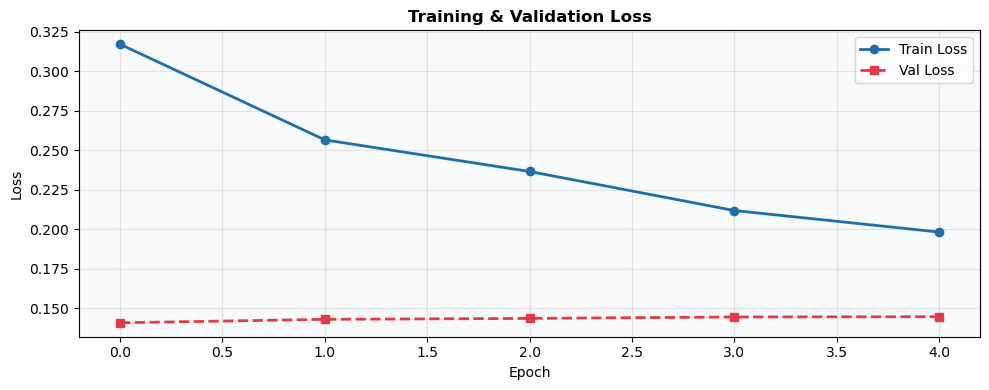

Best val_loss : 0.1409 (epoch 0)


In [37]:
METRICS_CSV = 'logs/gdl_experiment/version_11/metrics.csv'

try:
    metrics_df = pd.read_csv(METRICS_CSV)
    train_loss = metrics_df.dropna(subset=['train_loss'])[['epoch', 'train_loss']]
    val_loss   = metrics_df.dropna(subset=['val_loss'])[['epoch', 'val_loss']]

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(train_loss['epoch'], train_loss['train_loss'],
            marker='o', label='Train Loss', color='#1e6fa8', linewidth=2)
    ax.plot(val_loss['epoch'], val_loss['val_loss'],
            marker='s', label='Val Loss', color='#e63946', linewidth=2, linestyle='--')
    ax.set_title('Training & Validation Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_facecolor('#f8f9fa')

    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.savefig('outputs/07_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Best val_loss : {val_loss["val_loss"].min():.4f} (epoch {val_loss.loc[val_loss["val_loss"].idxmin(), "epoch"]})')

except FileNotFoundError:
    print('metrics.csv not found - update METRICS_CSV path above.')

## 8. Summary Card

In [38]:
# ── Final summary ──────────────────────────────────────────────────────────
best_class  = CLASS_NAMES[np.argmax(iou_per_class)]
worst_class = CLASS_NAMES[np.argmin(iou_per_class)]

print('\n' + '='*52)
print('  DOFA-EuroSAT Segmentation - Results Summary')
print('='*52)
print(f'  Model          : DOFA (Vision Transformer)')
print(f'  Dataset        : EuroSAT (10 classes, JPG)')
print(f'  Val samples    : {len(val_dataset)}')
print(f'  ' + '-'*45)
print(f'  mIoU           : {mean_iou:.3f}')
print(f'  Best class     : {best_class} ({max(iou_per_class):.3f})')
print(f'  Hardest class  : {worst_class} ({min(iou_per_class):.3f})')
print('='*52)
print()
print('Saved visualisations:')
for f in sorted(Path('outputs').glob('0*.png')):
    print(f'   {f}')


  DOFA-EuroSAT Segmentation - Results Summary
  Model          : DOFA (Vision Transformer)
  Dataset        : EuroSAT (10 classes, JPG)
  Val samples    : 5400
  ---------------------------------------------
  mIoU           : 0.262
  Best class     : Highway (0.604)
  Hardest class  : Forest (0.000)

Saved visualisations:
   outputs\00_class_palette.png
   outputs\01_class_distribution.png
   outputs\02_sample_patches.png
   outputs\03_predictions_grid.png
   outputs\04_error_maps.png
   outputs\05_iou_per_class.png
   outputs\06_confusion_matrix.png
   outputs\07_training_curves.png
